Saving images.jfif to images.jfif
Total Objects Detected: 7


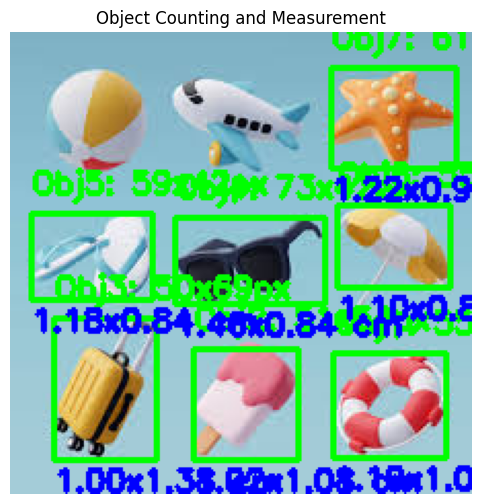

In [1]:
# Install required libraries
!pip install opencv-python-headless matplotlib numpy

# Import libraries
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

# Upload image
uploaded = files.upload()
image_path = list(uploaded.keys())[0]

# Read image
image = cv2.imread(image_path)
orig = image.copy()

# Convert to grayscale
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Apply Gaussian Blur
blur = cv2.GaussianBlur(gray, (7, 7), 0)

# Edge detection
edges = cv2.Canny(blur, 50, 150)

# Dilate edges
kernel = np.ones((3,3), np.uint8)
edges = cv2.dilate(edges, kernel, iterations=1)

# Find contours
contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Initialize object counter
object_count = 0

# (Optional) pixels per cm for real measurement
pixels_per_cm = 50   # Adjust if you know reference size

# Loop through contours
for cnt in contours:
    area = cv2.contourArea(cnt)

    # Ignore small noise
    if area > 500:
        object_count += 1

        # Bounding box
        x, y, w, h = cv2.boundingRect(cnt)

        # Draw rectangle
        cv2.rectangle(orig, (x, y), (x+w, y+h), (0, 255, 0), 2)

        # Measurement in pixels
        pixel_text = f"Obj{object_count}: {w}x{h}px"

        # Measurement in cm (optional)
        width_cm = w / pixels_per_cm
        height_cm = h / pixels_per_cm
        cm_text = f"{width_cm:.2f}x{height_cm:.2f} cm"

        # Put text
        cv2.putText(orig, pixel_text, (x, y-10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,255,0), 2)

        cv2.putText(orig, cm_text, (x, y+h+15),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255,0,0), 2)

# Print total count
print("Total Objects Detected:", object_count)

# Show result
plt.figure(figsize=(10,6))
plt.imshow(cv2.cvtColor(orig, cv2.COLOR_BGR2RGB))
plt.title("Object Counting and Measurement")
plt.axis('off')
plt.show()